## 피처 추출

**목적**: 피처 구간(2016-09 ~ 2018-03)의 주문 데이터를 바탕으로
고객 이탈 예측에 유효한 피처를 추출

**피처 그룹**
1. RFM(Recency, Frequency, Monetary)
2. 배송 관련 피처
3. 결제 관련 피처
4. 리뷰 관련 피처
5. 상품 다양성 피처
6. 이탈 레이블
---

## 0. 라이브러리 & 설정

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from pathlib import Path

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.0)

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')
FIGURES   = Path('../reports/figures')
PROCESSED.mkdir(parents=True, exist_ok=True)

# Time based Split 상수
FEATURE_START = pd.Timestamp('2016-09-01')
FEATURE_END   = pd.Timestamp('2018-03-31 23:59:59')
LABEL_START   = pd.Timestamp('2018-04-01')
LABEL_END     = pd.Timestamp('2018-10-31 23:59:59')

# Recency 기준일 = 피처 구간 마지막 날
REFERENCE_DATE = pd.Timestamp('2018-04-01')

---
## 1. 데이터 로드 & 날짜 파싱

In [42]:
orders = pd.read_csv('../data/raw/orders.csv')
items = pd.read_csv('../data/raw/order_items.csv')
payments= pd.read_csv('../data/raw/order_payments.csv')
products = pd.read_csv('../data/raw/products.csv')
customers = pd.read_csv('../data/raw/customers.csv')
sellers = pd.read_csv('../data/raw/sellers.csv')
reviews = pd.read_csv('../data/raw/order_reviews.csv')

dt_col = ['order_purchase_timestamp',
          'order_approved_at',
          'order_delivered_carrier_date',
          'order_delivered_customer_date',
          'order_estimated_delivery_date']

for col in dt_col:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')

---
## 2. 기본 필터링 & 테이블 병합

In [43]:
# customer_id → customer_unique_id 연결
orders = orders.merge(customers[['customer_id', 'customer_unique_id',
                                  'customer_state', 'customer_city']],
                      on='customer_id', how='left')

# delivered 주문만 사용 (취소, 미배송 제외)
orders_del = orders[orders['order_status'] == 'delivered'].copy()
print(f'delivered 주문: {len(orders_del):,}건')

# 피처 구간 필터링
feat_orders = orders_del[
    (orders_del['order_purchase_timestamp'] >= FEATURE_START) &
    (orders_del['order_purchase_timestamp'] <= FEATURE_END)
].copy()

delivered 주문: 96,478건


---
## 3. 이탈 레이블 생성

In [44]:
# 레이블 구간 재주문 고객
label_orders = orders_del[
    (orders_del['order_purchase_timestamp'] >= LABEL_START) &
    (orders_del['order_purchase_timestamp'] <= LABEL_END)
]
retained_customers = set(label_orders['customer_unique_id'].dropna().unique())

# 피처 구간 고객 목록
all_customers = feat_orders['customer_unique_id'].dropna().unique()

label_df = pd.DataFrame({'customer_unique_id': all_customers})
label_df['churned'] = (~label_df['customer_unique_id'].isin(retained_customers)).astype(int)

churn_rate = label_df['churned'].mean() * 100
print(f'총 분석 고객: {len(label_df):,}명')
print(f'이탈(1): {label_df["churned"].sum():,}명  ({churn_rate:.2f}%)')
print(f'유지(0): {(label_df["churned"]==0).sum():,}명  ({100-churn_rate:.2f}%)')

총 분석 고객: 62,299명
이탈(1): 61,696명  (99.03%)
유지(0): 603명  (0.97%)


---
## 4. 피처 그룹 1 - RFM

In [45]:
# 주문당 결제금액 집계
order_pay = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_pay.columns = ['order_id', 'order_payment_value']

feat_with_pay = feat_orders.merge(order_pay, on='order_id', how='left')

rfm = feat_with_pay.groupby('customer_unique_id').agg(
    # Recency: 기준일로부터 마지막 주문일까지의 일수 (작을수록 최근)
    recency       = ('order_purchase_timestamp',
                     lambda x: (REFERENCE_DATE - x.max()).days),
    # Frequency: 주문 횟수
    frequency     = ('order_id', 'nunique'),
    # Monetary: 총 결제금액 합계
    monetary_sum  = ('order_payment_value', 'sum'),
    # 평균 결제금액
    monetary_mean = ('order_payment_value', 'mean'),
).reset_index()

print('RFM 피처 샘플')
display(rfm.head())
print()
display(rfm.describe())

RFM 피처 샘플


,customer_unique_id,recency,frequency,monetary_sum,monetary_mean
0,0000f46a3911fa3c0805444483337064,386,1,86.22,86.22
1,0000f6ccb0745a6a4b88665a16c9f078,170,1,43.62,43.62
2,0004aac84e0df4da2b147fca70cf8255,137,1,196.89,196.89
3,00053a61a98854899e70ed204dd4bafe,31,1,419.18,419.18
4,0005e1862207bf6ccc02e4228effd9a0,392,1,150.12,150.12


,recency,frequency,monetary_sum,monetary_mean
count,62299.000000,62299.000000,62299.000000,62298.000000
mean,168.778439,1.032472,162.687721,158.057549
std,118.937749,0.202052,220.462090,213.979244
min,0.000000,1.000000,0.000000,10.070000
25%,69.000000,1.000000,62.585000,61.790000
50%,140.000000,1.000000,106.380000,104.370000
75%,256.000000,1.000000,180.605000,175.247500
max,562.000000,9.000000,13664.080000,13664.080000


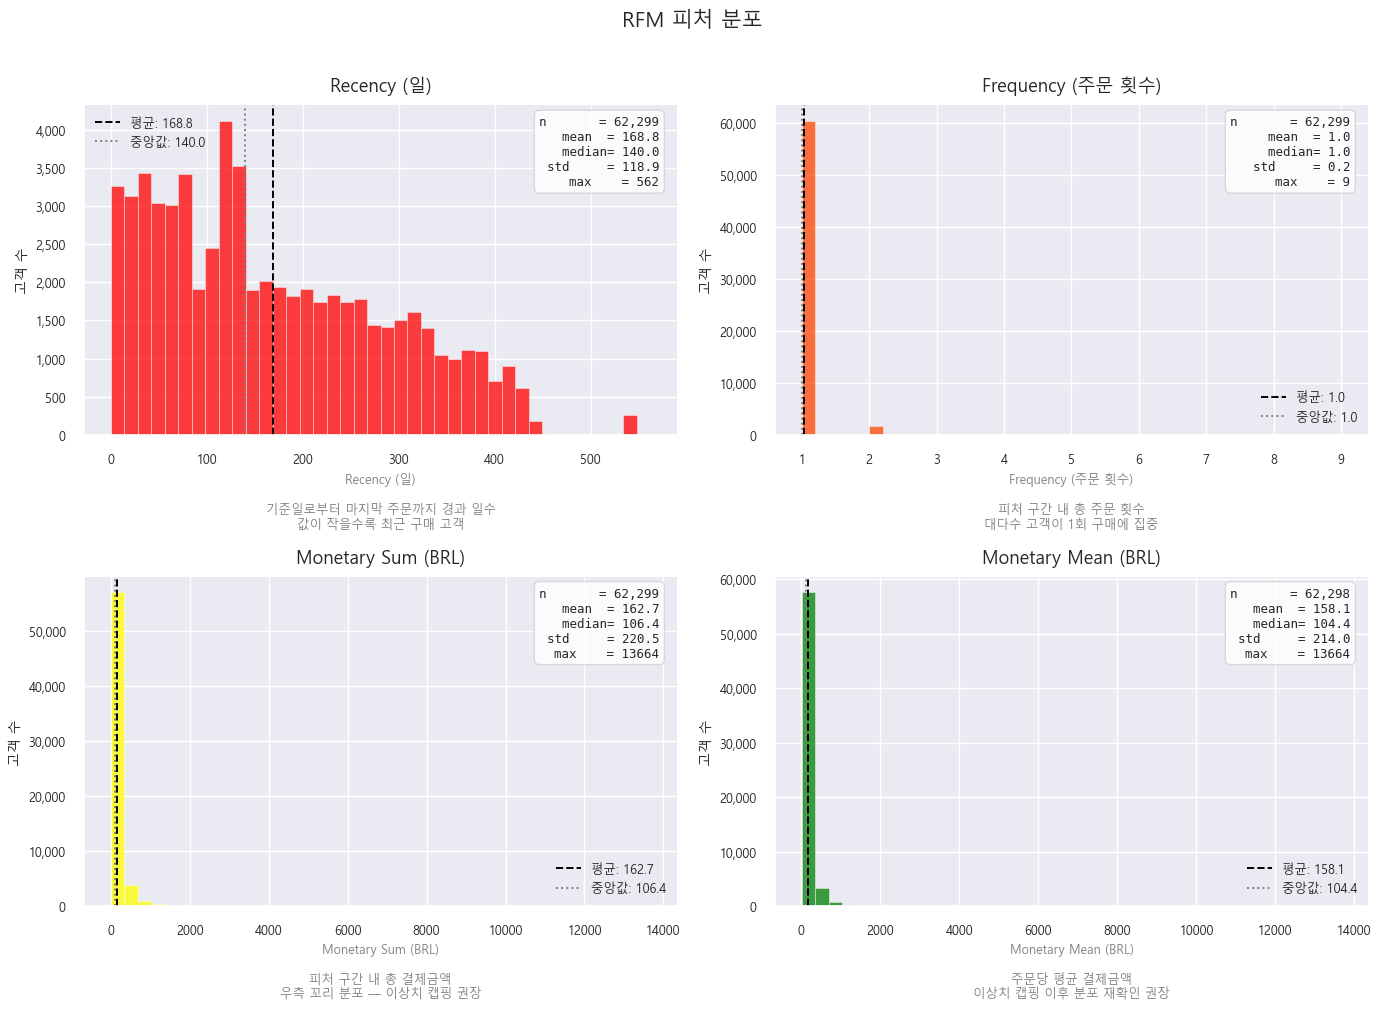

In [ ]:
# RFM 개별 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

rfm_configs = [
    ('recency',       'Recency (일)',          '#FF0000', '기준일로부터 마지막 주문까지 경과 일수'),
    ('frequency',     'Frequency (주문 횟수)', '#FF4500', '피처 구간 내 총 주문 횟수'),
    ('monetary_sum',  'Monetary Sum (BRL)',    '#FFFF00', '피처 구간 내 총 결제금액'),
    ('monetary_mean', 'Monetary Mean (BRL)',   '#008000', '주문당 평균 결제금액'),
]

for ax, (col, xlabel, color, desc) in zip(axes, rfm_configs):
    data = rfm[col].dropna()

    # 히스토그램
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)

    # 평균 / 중앙값 수직선
    mean_val   = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.4,
               label=f'평균: {mean_val:.1f}')
    ax.axvline(median_val, color='gray',   linestyle=':',  linewidth=1.4,
               label=f'중앙값: {median_val:.1f}')

    # 통계 텍스트 박스
    stats_text = (
        f'n       = {len(data):,}\n'
        f'mean  = {mean_val:.1f}\n'
        f'median= {median_val:.1f}\n'
        f'std     = {data.std():.1f}\n'
        f'max    = {data.max():.0f}'
    )
    ax.text(0.97, 0.97, stats_text,
            transform=ax.transAxes,
            fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='lightgray', alpha=0.85),
            fontfamily='monospace')

    ax.set_title(xlabel, fontsize=13, pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('고객 수', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlabel(f'{xlabel}\n\n{desc}', fontsize=9, color='gray')
    ax.tick_params(axis='both', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('RFM 피처 분포', fontsize=15, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'rfm_individual_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 피처 그룹 2 - 배송 피처

In [47]:
feat_orders = feat_orders.copy()

# 배송 소요일 (주문 → 수령)
feat_orders['delivery_days'] = (
    feat_orders['order_delivered_customer_date'] -
    feat_orders['order_purchase_timestamp']
).dt.days

# 배송 지연 일수 (수령일 - 예상 배송일, 음수=빠른 배송)
feat_orders['delivery_delay_days'] = (
    feat_orders['order_delivered_customer_date'] -
    feat_orders['order_estimated_delivery_date']
).dt.days

# 지연 여부 (1=지연, 0=정시)
feat_orders['is_delayed'] = (feat_orders['delivery_delay_days'] > 0).astype(int)

# 결제 승인 소요일 (주문 → 결제 승인)
feat_orders['approval_days'] = (
    feat_orders['order_approved_at'] -
    feat_orders['order_purchase_timestamp']
).dt.days

delivery_feats = feat_orders.groupby('customer_unique_id').agg(
    delivery_days_mean   = ('delivery_days', 'mean'),
    delivery_days_max    = ('delivery_days', 'max'),
    delay_days_mean      = ('delivery_delay_days', 'mean'),
    delay_days_max       = ('delivery_delay_days', 'max'),
    delayed_order_cnt    = ('is_delayed', 'sum'),
    delayed_order_rate   = ('is_delayed', 'mean'),
    approval_days_mean   = ('approval_days', 'mean'),
).reset_index()

display(delivery_feats.head())

,customer_unique_id,delivery_days_mean,delivery_days_max,delay_days_mean,delay_days_max,delayed_order_cnt,delayed_order_rate,approval_days_mean
0,0000f46a3911fa3c0805444483337064,25.0,25.0,-2.0,-2.0,0,0.0,0.0
1,0000f6ccb0745a6a4b88665a16c9f078,20.0,20.0,-12.0,-12.0,0,0.0,0.0
2,0004aac84e0df4da2b147fca70cf8255,13.0,13.0,-8.0,-8.0,0,0.0,0.0
3,00053a61a98854899e70ed204dd4bafe,16.0,16.0,-10.0,-10.0,0,0.0,0.0
4,0005e1862207bf6ccc02e4228effd9a0,4.0,4.0,-28.0,-28.0,0,0.0,0.0


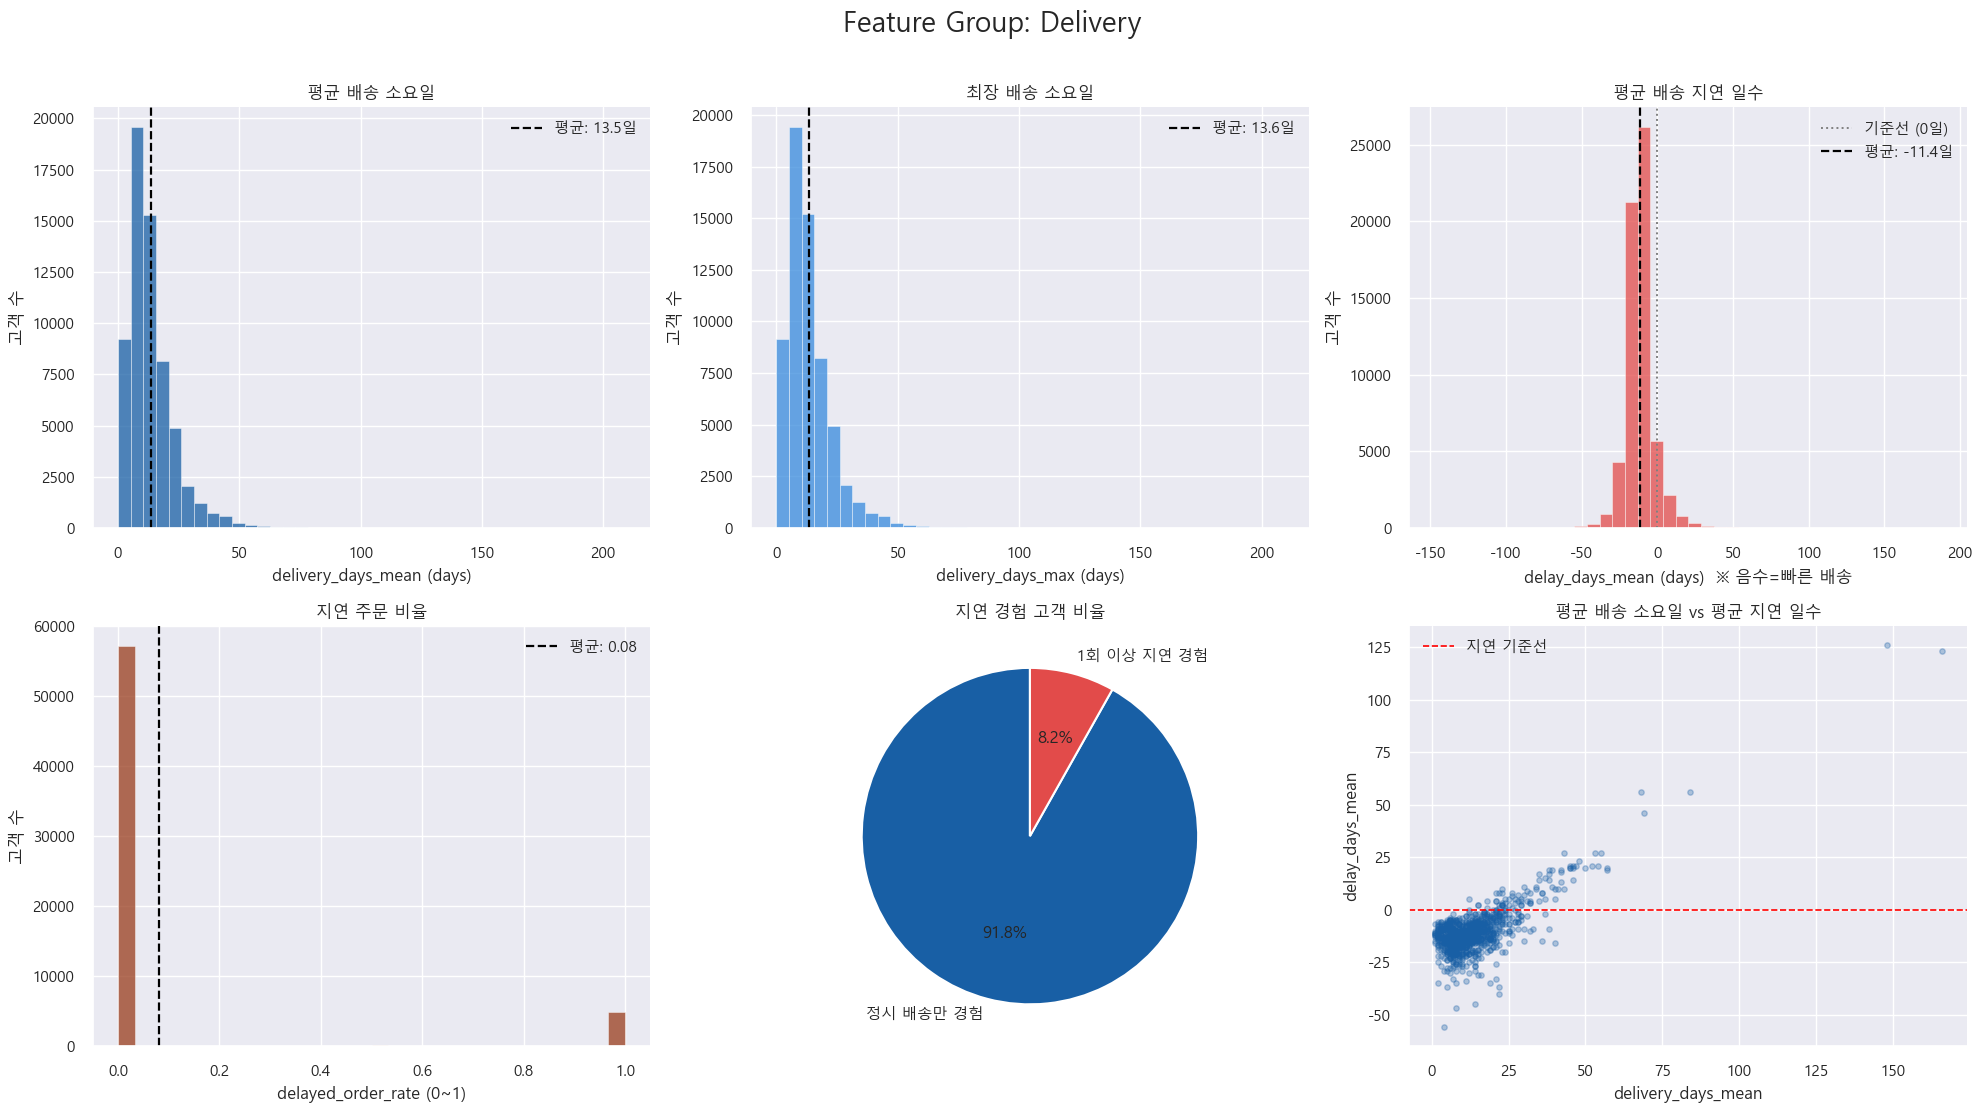

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

# 1) 평균 배송 소요일 분포
axes[0].hist(delivery_feats['delivery_days_mean'].dropna(), bins=40,
             color='#185FA5', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[0].axvline(delivery_feats['delivery_days_mean'].mean(), color='black',
                linestyle='--', linewidth=1.6, label=f"평균: {delivery_feats['delivery_days_mean'].mean():.1f}일")
axes[0].set_title('평균 배송 소요일')
axes[0].set_xlabel('delivery_days_mean (days)')
axes[0].set_ylabel('고객 수')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# 2) 최장 배송 소요일 분포
axes[1].hist(delivery_feats['delivery_days_max'].dropna(), bins=40,
             color='#378ADD', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[1].axvline(delivery_feats['delivery_days_max'].mean(), color='black',
                linestyle='--', linewidth=1.6, label=f"평균: {delivery_feats['delivery_days_max'].mean():.1f}일")
axes[1].set_title('최장 배송 소요일')
axes[1].set_xlabel('delivery_days_max (days)')
axes[1].set_ylabel('고객 수')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# 3) 평균 배송 지연 일수 분포
axes[2].hist(delivery_feats['delay_days_mean'].dropna(), bins=40,
             color='#E24B4A', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[2].axvline(0, color='gray', linestyle=':', linewidth=1.4, label='기준선 (0일)')
axes[2].axvline(delivery_feats['delay_days_mean'].mean(), color='black',
                linestyle='--', linewidth=1.6, label=f"평균: {delivery_feats['delay_days_mean'].mean():.1f}일")
axes[2].set_title('평균 배송 지연 일수')
axes[2].set_xlabel('delay_days_mean (days)  ※ 음수=빠른 배송')
axes[2].set_ylabel('고객 수')
axes[2].legend()
axes[2].spines[['top','right']].set_visible(False)

# 4) 지연 주문 비율 분포
axes[3].hist(delivery_feats['delayed_order_rate'].dropna(), bins=30,
             color='#993C1D', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[3].axvline(delivery_feats['delayed_order_rate'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: {delivery_feats['delayed_order_rate'].mean():.2f}")
axes[3].set_title('지연 주문 비율')
axes[3].set_xlabel('delayed_order_rate (0~1)')
axes[3].set_ylabel('고객 수')
axes[3].legend()
axes[3].spines[['top','right']].set_visible(False)

# 5) 지연 vs 정시 고객 비율 (파이)
delayed_cnt  = (delivery_feats['delayed_order_rate'] > 0).sum()
on_time_cnt  = (delivery_feats['delayed_order_rate'] == 0).sum()
axes[4].pie([on_time_cnt, delayed_cnt],
            labels=['정시 배송만 경험', '1회 이상 지연 경험'],
            autopct='%1.1f%%',
            colors=['#185FA5', '#E24B4A'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[4].set_title('지연 경험 고객 비율')

# 6) 배송 소요일 vs 지연 일수 산점도
sample = delivery_feats.sample(min(1000, len(delivery_feats)), random_state=42)
axes[5].scatter(sample['delivery_days_mean'], sample['delay_days_mean'],
                alpha=0.3, s=15, color='#185FA5')
axes[5].axhline(0, color='red', linestyle='--', linewidth=1.2, label='지연 기준선')
axes[5].set_title('평균 배송 소요일 vs 평균 지연 일수')
axes[5].set_xlabel('delivery_days_mean')
axes[5].set_ylabel('delay_days_mean')
axes[5].legend()
axes[5].spines[['top','right']].set_visible(False)

plt.suptitle('Feature Group: Delivery', fontsize=20, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/feat_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 피처 그룹 3 - 결제 피처

In [49]:
# 피처 구간 주문만 필터링
feat_pay = payments[payments['order_id'].isin(feat_orders['order_id'])].copy()

# 주문별 주 결제 수단 (결제금액 기준 최대)
main_pay = (
    feat_pay.sort_values('payment_value', ascending=False)
    .groupby('order_id')['payment_type'].first()
    .reset_index()
)
feat_orders_pay = feat_orders.merge(main_pay, on='order_id', how='left')

# 주문별 할부 개월수 (신용카드 주문 한정)
installment = (
    feat_pay[feat_pay['payment_type'] == 'credit_card']
    .groupby('order_id')['payment_installments'].max()
    .reset_index()
)
feat_orders_pay = feat_orders_pay.merge(installment, on='order_id', how='left')
feat_orders_pay['payment_installments'] = feat_orders_pay['payment_installments'].fillna(1)

# 결제 수단별 더미 변수를 고객 수준에서 집계
pay_dummies = pd.get_dummies(feat_orders_pay['payment_type'], prefix='pay')
feat_orders_pay = pd.concat([feat_orders_pay, pay_dummies], axis=1)

pay_dummy_cols = [c for c in feat_orders_pay.columns if c.startswith('pay_')]

payment_agg_dict = {
    'payment_installments': ['mean', 'max'],
}
for col in pay_dummy_cols:
    payment_agg_dict[col] = 'sum'

payment_feats = feat_orders_pay.groupby('customer_unique_id').agg(payment_agg_dict).reset_index()
payment_feats.columns = ['customer_unique_id'] + [
    f'{c[0]}_{c[1]}' if c[1] else c[0]
    for c in payment_feats.columns[1:]
]

# 할부 사용 여부 (최대 할부 개월수 > 1)
payment_feats['used_installment'] = (payment_feats['payment_installments_max'] > 1).astype(int)

display(payment_feats.head())

,customer_unique_id,payment_installments_mean,payment_installments_max,pay_boleto_sum,pay_credit_card_sum,pay_debit_card_sum,pay_voucher_sum,used_installment
0,0000f46a3911fa3c0805444483337064,8.0,8.0,0,1,0,0,1
1,0000f6ccb0745a6a4b88665a16c9f078,4.0,4.0,0,1,0,0,1
2,0004aac84e0df4da2b147fca70cf8255,6.0,6.0,0,1,0,0,1
3,00053a61a98854899e70ed204dd4bafe,3.0,3.0,0,1,0,0,1
4,0005e1862207bf6ccc02e4228effd9a0,3.0,3.0,0,1,0,0,1


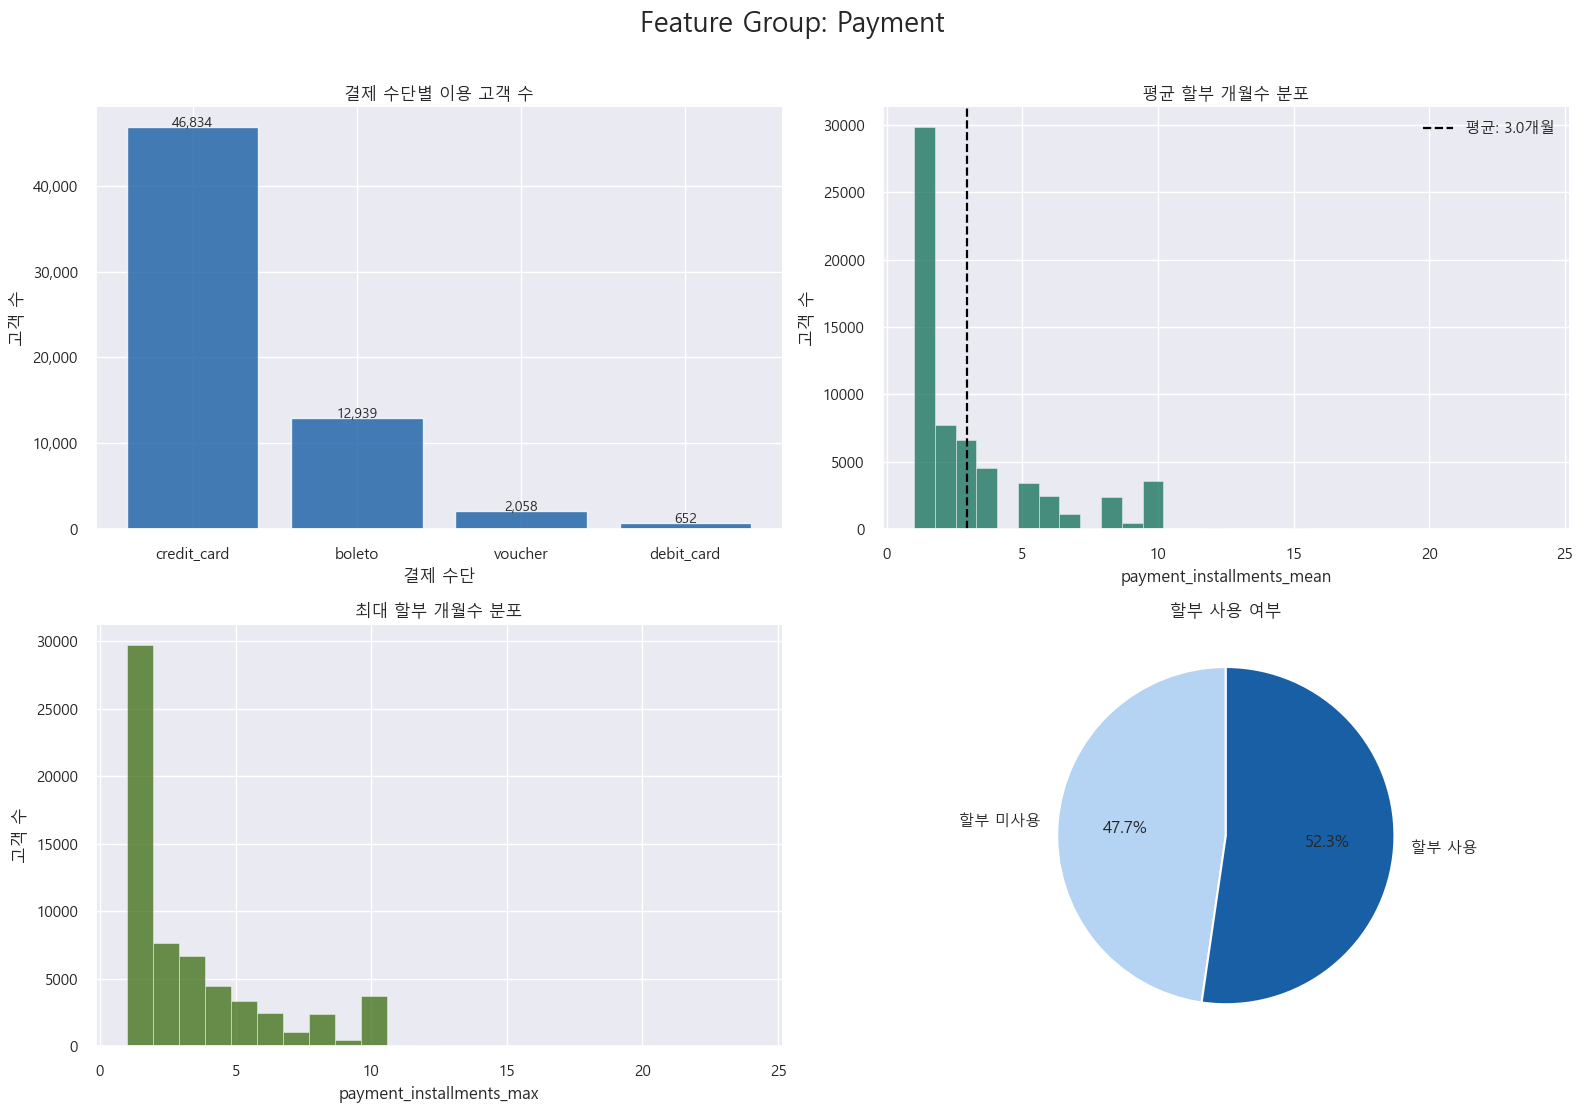

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

# 1) 결제 수단별 이용 고객 수 (bar)
pay_cols = [c for c in payment_feats.columns if c.startswith('pay_') and c.endswith('_sum')]
pay_totals = payment_feats[pay_cols].gt(0).sum().sort_values(ascending=False)
pay_totals.index = pay_totals.index.str.replace('pay_', '').str.replace('_sum', '')

axes[0].bar(pay_totals.index, pay_totals.values,
            color='#185FA5', alpha=0.8, edgecolor='white')
axes[0].set_title('결제 수단별 이용 고객 수')
axes[0].set_xlabel('결제 수단')
axes[0].set_ylabel('고객 수')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(pay_totals.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# 2) 평균 할부 개월수 분포
axes[1].hist(payment_feats['payment_installments_mean'].dropna(), bins=30,
             color='#0F6E56', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[1].axvline(payment_feats['payment_installments_mean'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: {payment_feats['payment_installments_mean'].mean():.1f}개월")
axes[1].set_title('평균 할부 개월수 분포')
axes[1].set_xlabel('payment_installments_mean')
axes[1].set_ylabel('고객 수')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# 3) 최대 할부 개월수 분포
axes[2].hist(payment_feats['payment_installments_max'].dropna(), bins=24,
             color='#3B6D11', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[2].set_title('최대 할부 개월수 분포')
axes[2].set_xlabel('payment_installments_max')
axes[2].set_ylabel('고객 수')
axes[2].spines[['top','right']].set_visible(False)

# 4) 할부 사용 여부 (파이)
inst_cnt    = payment_feats['used_installment'].value_counts().sort_index()
axes[3].pie(inst_cnt.values,
            labels=['할부 미사용', '할부 사용'],
            autopct='%1.1f%%',
            colors=['#B5D4F4', '#185FA5'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[3].set_title('할부 사용 여부')

plt.suptitle('Feature Group: Payment', fontsize=20, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/feat_payment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 피처 그룹 4 - 리뷰 피처

In [51]:
# 피처 구간 주문의 리뷰만
feat_reviews = reviews[reviews['order_id'].isin(feat_orders['order_id'])].copy()

# order_id → customer_unique_id 매핑
order_cust_map = feat_orders[['order_id', 'customer_unique_id']].drop_duplicates()
feat_reviews = feat_reviews.merge(order_cust_map, on='order_id', how='left')

review_feats = feat_reviews.groupby('customer_unique_id').agg(
    review_score_mean    = ('review_score', 'mean'),
    review_score_min     = ('review_score', 'min'),
    review_score_max     = ('review_score', 'max'),
    review_cnt           = ('review_id', 'nunique'),
    # 불만 리뷰 비율 (1~2점)
    low_score_rate       = ('review_score', lambda x: (x <= 2).mean()),
    # 댓글 작성 여부
    has_comment_rate     = ('review_comment_message',
                            lambda x: x.notna().mean()),
).reset_index()

print('리뷰 피처 샘플')
display(review_feats.head())

# 리뷰가 없는 고객 → 리뷰 피처 결측 처리 방침
review_null_ratio = 1 - feat_orders['customer_unique_id'].isin(
    feat_reviews['customer_unique_id']).mean()
print(f'\n리뷰 없는 고객 비율: {review_null_ratio*100:.1f}% → 병합 후 fillna 처리 예정')

리뷰 피처 샘플


,customer_unique_id,review_score_mean,review_score_min,review_score_max,review_cnt,low_score_rate,has_comment_rate
0,0000f46a3911fa3c0805444483337064,3.0,3,3,1,0.0,0.0
1,0000f6ccb0745a6a4b88665a16c9f078,4.0,4,4,1,0.0,1.0
2,0004aac84e0df4da2b147fca70cf8255,5.0,5,5,1,0.0,0.0
3,00053a61a98854899e70ed204dd4bafe,1.0,1,1,1,1.0,1.0
4,0005e1862207bf6ccc02e4228effd9a0,4.0,4,4,1,0.0,0.0



리뷰 없는 고객 비율: 0.7% → 병합 후 fillna 처리 예정


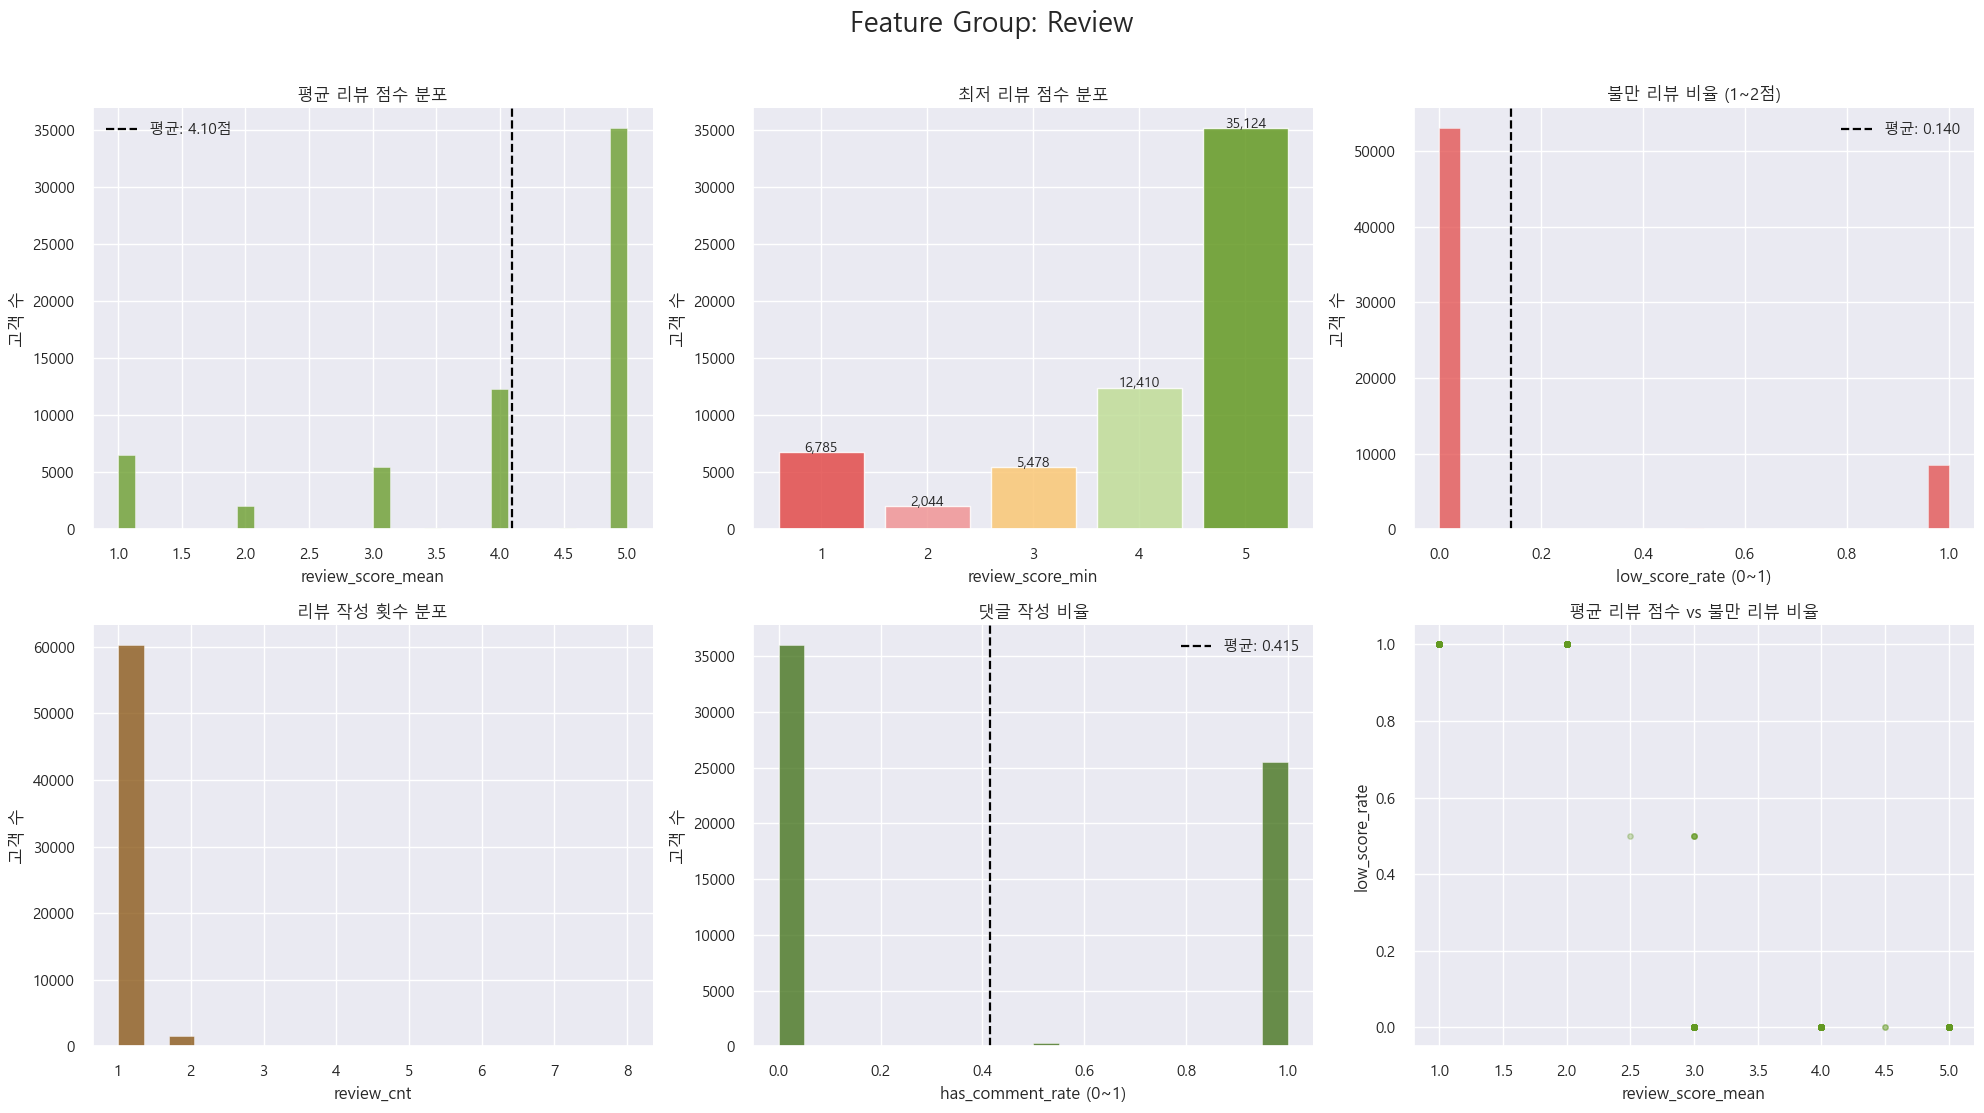

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

# 1) 평균 리뷰 점수 분포
axes[0].hist(review_feats['review_score_mean'].dropna(), bins=30,
             color='#639922', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[0].axvline(review_feats['review_score_mean'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: {review_feats['review_score_mean'].mean():.2f}점")
axes[0].set_title('평균 리뷰 점수 분포')
axes[0].set_xlabel('review_score_mean')
axes[0].set_ylabel('고객 수')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# 2) 최저 리뷰 점수 분포 (bar)
min_score_cnt = review_feats['review_score_min'].value_counts().sort_index()
colors_score  = ['#E24B4A','#F09595','#FAC775','#C0DD97','#639922']
axes[1].bar(min_score_cnt.index, min_score_cnt.values,
            color=colors_score, alpha=0.85, edgecolor='white')
axes[1].set_title('최저 리뷰 점수 분포')
axes[1].set_xlabel('review_score_min')
axes[1].set_ylabel('고객 수')
axes[1].set_xticks([1,2,3,4,5])
for i, (x, v) in enumerate(zip(min_score_cnt.index, min_score_cnt.values)):
    axes[1].text(x, v + 20, f'{v:,}', ha='center', fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

# 3) 불만 리뷰 비율 분포
axes[2].hist(review_feats['low_score_rate'].dropna(), bins=25,
             color='#E24B4A', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[2].axvline(review_feats['low_score_rate'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: {review_feats['low_score_rate'].mean():.3f}")
axes[2].set_title('불만 리뷰 비율 (1~2점)')
axes[2].set_xlabel('low_score_rate (0~1)')
axes[2].set_ylabel('고객 수')
axes[2].legend()
axes[2].spines[['top','right']].set_visible(False)

# 4) 리뷰 작성 횟수 분포
axes[3].hist(review_feats['review_cnt'].dropna(), bins=20,
             color='#854F0B', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[3].set_title('리뷰 작성 횟수 분포')
axes[3].set_xlabel('review_cnt')
axes[3].set_ylabel('고객 수')
axes[3].spines[['top','right']].set_visible(False)

# 5) 댓글 작성 비율 분포
axes[4].hist(review_feats['has_comment_rate'].dropna(), bins=20,
             color='#3B6D11', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[4].axvline(review_feats['has_comment_rate'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: {review_feats['has_comment_rate'].mean():.3f}")
axes[4].set_title('댓글 작성 비율')
axes[4].set_xlabel('has_comment_rate (0~1)')
axes[4].set_ylabel('고객 수')
axes[4].legend()
axes[4].spines[['top','right']].set_visible(False)

# 6) 평균 리뷰 점수 vs 불만 리뷰 비율 산점도
sample_r = review_feats.sample(min(1000, len(review_feats)), random_state=42)
axes[5].scatter(sample_r['review_score_mean'], sample_r['low_score_rate'],
                alpha=0.3, s=15, color='#639922')
axes[5].set_title('평균 리뷰 점수 vs 불만 리뷰 비율')
axes[5].set_xlabel('review_score_mean')
axes[5].set_ylabel('low_score_rate')
axes[5].spines[['top','right']].set_visible(False)

plt.suptitle('Feature Group: Review', fontsize=20, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/feat_review.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 피처 그룹 5 - 상품 다양성 & 주문 규모 피처

In [53]:
# 피처 구간 주문의 아이템
feat_items = items[items['order_id'].isin(feat_orders['order_id'])].copy()
feat_items = feat_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
feat_items = feat_items.merge(order_cust_map, on='order_id', how='left')

product_feats = feat_items.groupby('customer_unique_id').agg(
    # 총 구매 아이템 수
    total_items           = ('order_item_id', 'sum'),
    # 평균 주문당 아이템 수
    avg_items_per_order   = ('order_item_id', 'mean'),
    # 구매한 고유 상품 수
    unique_products       = ('product_id', 'nunique'),
    # 구매한 고유 카테고리 수 (다양성)
    unique_categories     = ('product_category_name', 'nunique'),
    # 총 운송비
    freight_total         = ('freight_value', 'sum'),
    # 평균 상품 가격
    avg_product_price     = ('price', 'mean'),
    # 최고 단가 상품
    max_product_price     = ('price', 'max'),
).reset_index()

print('상품 피처 샘플')
display(product_feats.head())

상품 피처 샘플


,customer_unique_id,total_items,avg_items_per_order,unique_products,unique_categories,freight_total,avg_product_price,max_product_price
0,0000f46a3911fa3c0805444483337064,1,1.0,1,1,17.22,69.00,69.00
1,0000f6ccb0745a6a4b88665a16c9f078,1,1.0,1,1,17.63,25.99,25.99
2,0004aac84e0df4da2b147fca70cf8255,1,1.0,1,1,16.89,180.00,180.00
3,00053a61a98854899e70ed204dd4bafe,3,1.5,2,1,37.18,191.00,191.00
4,0005e1862207bf6ccc02e4228effd9a0,1,1.0,1,1,15.12,135.00,135.00


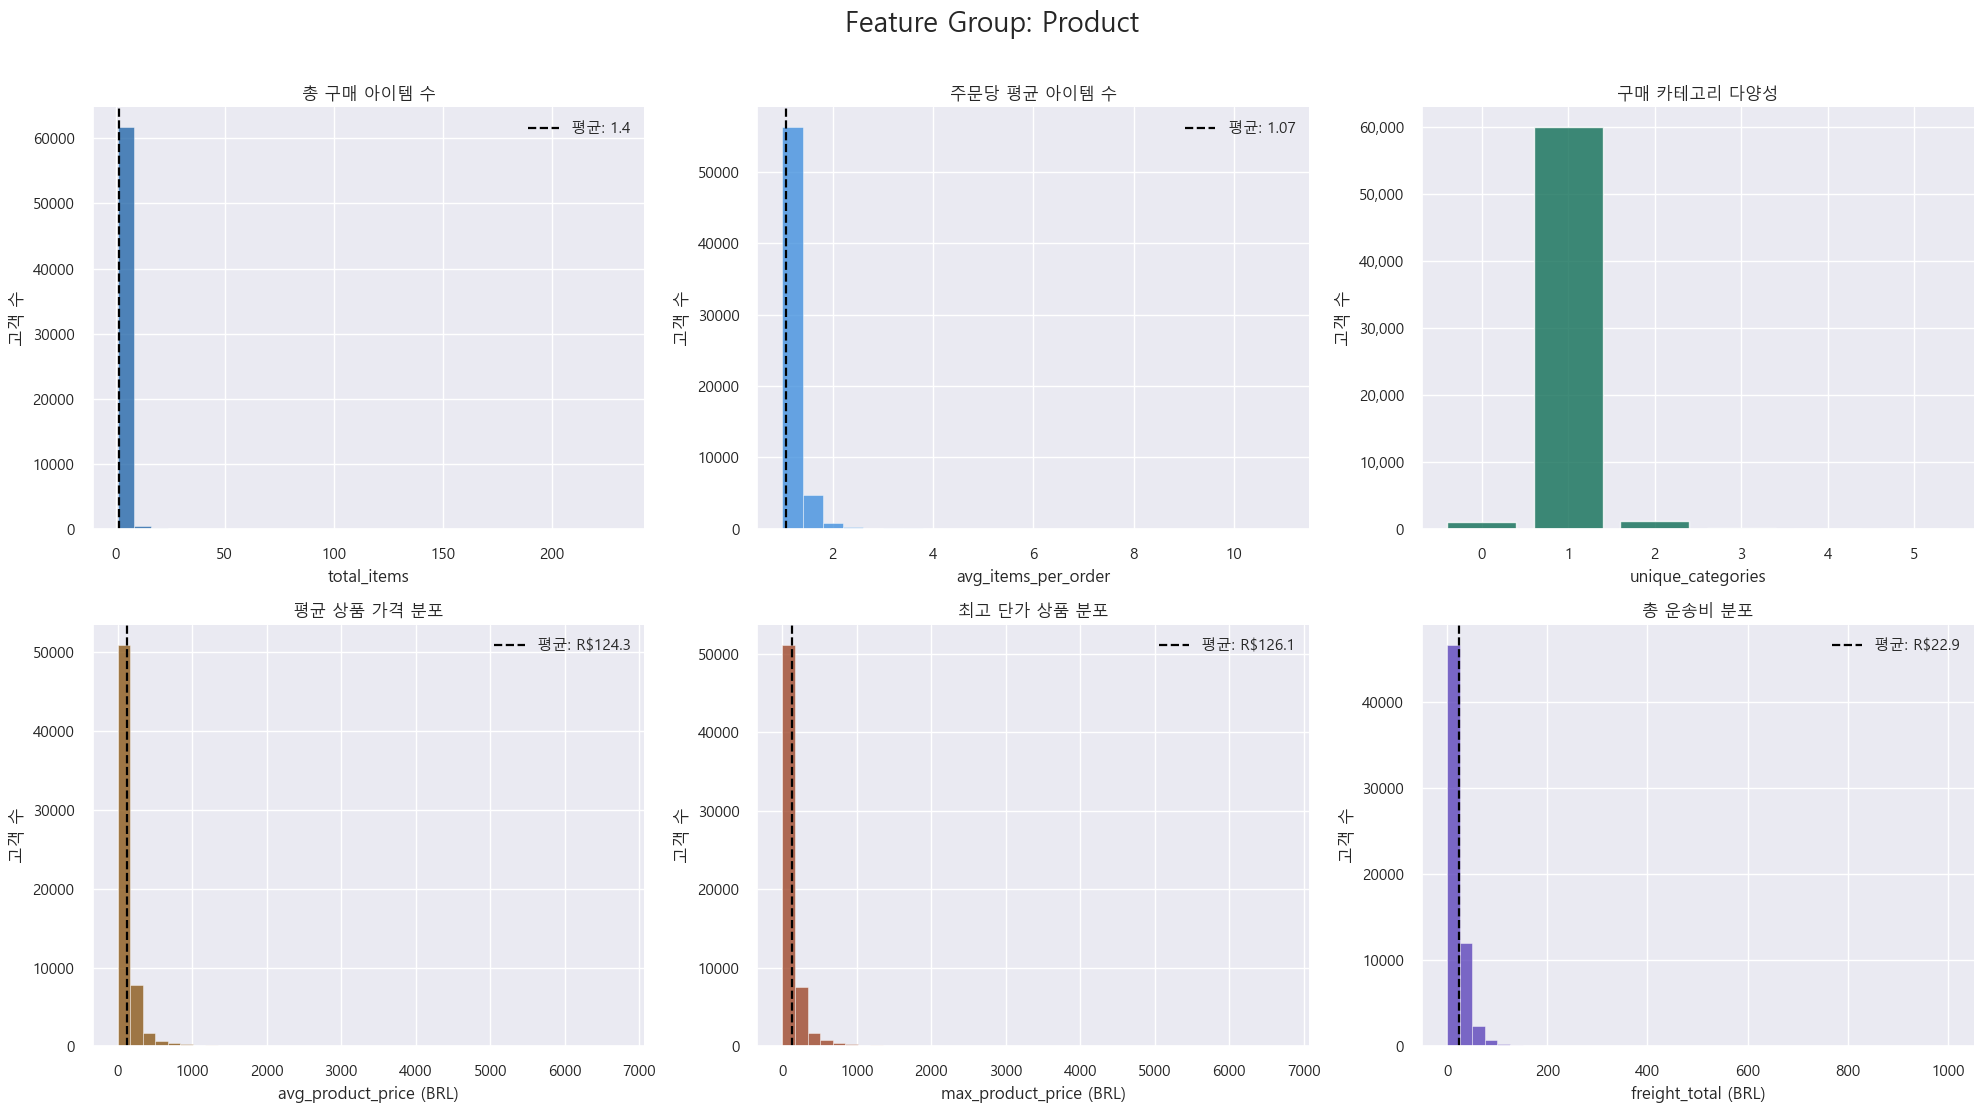

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

# 1) 총 구매 아이템 수
axes[0].hist(product_feats['total_items'].dropna(), bins=30,
             color='#185FA5', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[0].axvline(product_feats['total_items'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: {product_feats['total_items'].mean():.1f}")
axes[0].set_title('총 구매 아이템 수')
axes[0].set_xlabel('total_items')
axes[0].set_ylabel('고객 수')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# 2) 주문당 평균 아이템 수
axes[1].hist(product_feats['avg_items_per_order'].dropna(), bins=25,
             color='#378ADD', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[1].axvline(product_feats['avg_items_per_order'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: {product_feats['avg_items_per_order'].mean():.2f}")
axes[1].set_title('주문당 평균 아이템 수')
axes[1].set_xlabel('avg_items_per_order')
axes[1].set_ylabel('고객 수')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# 3) 구매 카테고리 다양성
cat_cnt = product_feats['unique_categories'].value_counts().sort_index()
axes[2].bar(cat_cnt.index, cat_cnt.values,
            color='#0F6E56', alpha=0.8, edgecolor='white')
axes[2].set_title('구매 카테고리 다양성')
axes[2].set_xlabel('unique_categories')
axes[2].set_ylabel('고객 수')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[2].spines[['top','right']].set_visible(False)

# 4) 평균 상품 가격 분포
axes[3].hist(product_feats['avg_product_price'].dropna(), bins=40,
             color='#854F0B', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[3].axvline(product_feats['avg_product_price'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: R${product_feats['avg_product_price'].mean():.1f}")
axes[3].set_title('평균 상품 가격 분포')
axes[3].set_xlabel('avg_product_price (BRL)')
axes[3].set_ylabel('고객 수')
axes[3].legend()
axes[3].spines[['top','right']].set_visible(False)

# 5) 최고 단가 상품 분포
axes[4].hist(product_feats['max_product_price'].dropna(), bins=40,
             color='#993C1D', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[4].axvline(product_feats['max_product_price'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: R${product_feats['max_product_price'].mean():.1f}")
axes[4].set_title('최고 단가 상품 분포')
axes[4].set_xlabel('max_product_price (BRL)')
axes[4].set_ylabel('고객 수')
axes[4].legend()
axes[4].spines[['top','right']].set_visible(False)

# 6) 총 운송비 분포
axes[5].hist(product_feats['freight_total'].dropna(), bins=40,
             color='#533AB7', alpha=0.75, edgecolor='white', linewidth=0.4)
axes[5].axvline(product_feats['freight_total'].mean(), color='black',
                linestyle='--', linewidth=1.6,
                label=f"평균: R${product_feats['freight_total'].mean():.1f}")
axes[5].set_title('총 운송비 분포')
axes[5].set_xlabel('freight_total (BRL)')
axes[5].set_ylabel('고객 수')
axes[5].legend()
axes[5].spines[['top','right']].set_visible(False)

plt.suptitle('Feature Group: Product', fontsize=20, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/feat_product.png', dpi=150, bbox_inches='tight')
plt.show()